# Hedging the Dollar Beta of the Carry Book with DXY

**Author: Arjun**

The next piece of work is a **DXY-futures overlay**: can we hedge part of the carry book's
dollar exposure with a single liquid instrument (ICE DXY futures) and improve the risk-adjusted
return? Before pulling any futures data, this notebook does the **measurement step** that decides
whether such an overlay is even worth building — and, if so, how big it should be.

> **"How much of what the carry book does is just the dollar, and how well does DXY capture it?"**

**Why regress first, and why on DXY *spot* now.** DXY futures returns are essentially spot + roll;
their daily return correlation with the spot index is ~0.99, so the **hedge ratio** (the beta we
need) can be estimated off the spot index we already have in `data/raw/`. The futures data matters
for *implementation* — the tradable contract, roll dates, transaction costs — not for sizing the
exposure. So the right order is: **measure the beta on spot now, refine with futures later.**

**What this notebook establishes**

1. **Which dollar?** DXY is a specific, EUR-heavy basket of six majors with **no EM**. We contrast
   it with the equal-weighted dollar factor (DOL) the book actually lives against, so we know what
   we are — and are not — hedging.
2. **Per-currency dollar betas** — regress each currency on DXY to see which legs are dollar-driven
   and how mechanically (some currencies *are* DXY constituents).
3. **Book-level dollar beta** — the load-bearing number: regress the G10, EM-only and combined
   book P&L on DXY. The book is built dollar-neutral, so this measures the *residual* net dollar
   tilt an overlay would target.
4. **Is the beta stable?** Rolling betas — a static full-sample hedge ratio is a poor hedge if the
   exposure moves around (and this project has shown everything here is regime-dependent).
5. **What a DXY hedge would remove** — an in-sample, spot-proxy preview of the vol/Sharpe effect,
   framed as the hypothesis the futures backtest will actually test.
6. **Does it help where it fits?** — the same hedge restricted to only the currencies DXY tracks
   well (high $R^2$), the best-case shot for the instrument.

All conventions follow the team engine (`cesare/fx_utils.py`): no lookahead, Newey–West HAC
inference, common window 2007-05 → 2026-06.

## 0. Setup — engine, panels, canonical books

Same panel chain and book construction as `cesare/strategy_backtest.ipynb` and my
`em_carry_attribution.ipynb`, imported from the shared `fx_utils`. We rebuild the three books
(G10, EM-only, combined) gross **and** net of costs, and gate them against the committed Sharpes so
the dollar-beta analysis sits on the same numbers as the rest of the repo.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

CESARE = Path("../cesare").resolve()
sys.path.insert(0, str(CESARE))
import fx_utils as fx

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
ou
OUTPUTS = CESARE / "outputs"          # committed team results (read-only)
OUT = Path("tputs"); OUT.mkdir(exist_ok=True)   # my deliverables land here
print("fx_utils loaded from", fx.__file__)

fx_utils loaded from /Users/arjunpatel/GitRepositories/FX_Carry_26_Summer_PL/cesare/fx_utils.py


In [2]:
# --- core panels ---
g10_px = fx.load_wide("g10_fx_spot_forward")
em_px  = fx.load_wide("em_fx_spot_forward")
spots  = fx.spots_usd_per_fx(g10_px, em_px)
carry  = fx.carry_panel(g10_px, em_px, tenor="1M")
xret   = fx.excess_returns(spots, carry)          # daily book P&L building block
sret   = fx.spot_log_returns(spots)               # spot-only move (what DXY actually hedges)

UNIVERSE_G10 = ["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]
UNIVERSE_ALL = [c for c in xret.columns if c not in ("HKD", "DKK", "CNY")]
UNIVERSE_EM  = [c for c in UNIVERSE_ALL if c not in UNIVERSE_G10]
VOL_TARGET = 0.10

# --- DXY spot: up = USD stronger (the mirror image of our USD-per-FX spots) ---
dxy_lvl = fx.load_wide("global_risk")["DXY"].rename("DXY")
dxy_ret = np.log(dxy_lvl).diff().rename("DXY")     # daily log return of the dollar index

print(f"G10={len(UNIVERSE_G10)}  EM={len(UNIVERSE_EM)}  combined={len(UNIVERSE_ALL)}")
print(f"DXY spot: {dxy_lvl.dropna().index.min().date()} -> {dxy_lvl.dropna().index.max().date()}  "
      f"({dxy_lvl.notna().sum():,} obs)")

G10=9  EM=18  combined=27
DXY spot: 2007-01-02 -> 2026-06-30  (5,071 obs)


In [3]:
# --- build the books (unit sort -> vol target -> gross, and net of costs) ---
hs_out, hs_pts = fx.forward_halfspreads(tenor="1M")

def build_book(universe, n_buckets, name="book"):
    w_unit = fx.carry_portfolio(carry, xret, n_buckets=n_buckets, universe=universe)
    w_vt   = fx.vol_target_weights(w_unit, xret, target=VOL_TARGET)
    gross  = fx.portfolio_returns(w_vt, xret, f"{name}_gross")
    net    = (gross - fx.roundtrip_cost(w_vt, hs_out, hs_pts)).rename(f"{name}_net")
    return gross, net, w_vt

g10_gross, g10_net, w_g10 = build_book(UNIVERSE_G10, 3, "G10")
all_gross, all_net, w_all = build_book(UNIVERSE_ALL, 5, "ALL")
em_gross,  em_net,  w_em  = build_book(UNIVERSE_EM, 3, "EM")

# reconciliation gate vs committed numbers
committed = pd.read_csv(OUTPUTS / "strategy_summary_stats.csv", index_col=0)
def sharpe(r):
    r = r.dropna(); return r.mean() * fx.ANN_DAYS / (r.std() * np.sqrt(fx.ANN_DAYS))
recon = pd.DataFrame({
    "G10_net": [sharpe(g10_net), committed.loc["G10_net", "sharpe"]],
    "ALL_net": [sharpe(all_net), committed.loc["ALL_net", "sharpe"]],
}, index=["rebuilt", "committed"]).T
recon["abs_diff"] = (recon["rebuilt"] - recon["committed"]).abs()
assert (recon["abs_diff"] < 5e-3).all(), "Reconciliation FAILED."
print(recon.round(4).to_string()); print("Reconciliation PASSED.")

WIN0, WIN1 = all_net.dropna().index[[0, -1]]
def win(s): return s.loc[WIN0:WIN1]
print("common window:", WIN0.date(), "->", WIN1.date())

         rebuilt  committed  abs_diff
G10_net   0.1191     0.1191       0.0
ALL_net   0.4659     0.4659       0.0
Reconciliation PASSED.
common window: 2007-05-01 -> 2026-06-30


## 1. Which dollar are we talking about?

Two different "dollars" show up in this analysis, and keeping them separate is the whole game.

**DXY (what we can trade).** The ICE Dollar Index is a fixed-weight basket of **six** currencies,
and it is dominated by the euro:

| Currency | DXY weight | In our book? |
|---|---:|---|
| EUR | 57.6% | yes (short leg, usually) |
| JPY | 13.6% | yes |
| GBP | 11.9% | yes |
| CAD | 9.1% | yes |
| SEK | 4.2% | yes |
| CHF | 3.6% | yes |
| **EM (all)** | **0%** | **19 names — the entire premium** |
| AUD, NZD, NOK | 0% | yes |

So DXY is really a *"EUR + a few majors"* index. It contains **none** of the EM currencies that
carry the premium (`em_carry_attribution.ipynb`: IDR/JPY/MXN/BRL/COP ≈ 65% of P&L).

**DOL (what the book lives against).** The dollar factor from the carry literature (Lustig–
Roussanov–Verdelhan) is the **equal-weighted** average return of being long every currency vs USD —
`fx.dollar_factor(xret)`. It spans the book's *own* universe, EM included. It is the *representative*
dollar but is **not directly tradable** as one instrument.

Below: cumulative "USD strength" from DXY vs from the broad book universe (`−DOL`, i.e. long-USD /
short-all-FX, put on the same up-=-USD footing), and their rolling correlation. The gap between them
is exactly the tracking error we accept by hedging with a real instrument instead of the ideal
basket.

full-sample daily corr(DXY, broad-USD spot)   = 0.780
full-sample daily corr(DXY, broad-USD excess) = 0.780

cumulative to 2026-06-30 (log return):
  DXY                 +0.203
  -DOL spot           +0.449   <- composition gap vs DXY
  -DOL excess         +0.044   <- adds the carry drag

  gap DXY - (-DOL spot)   = -0.247  (composition)
  carry drag              = +0.406  (interest differential)


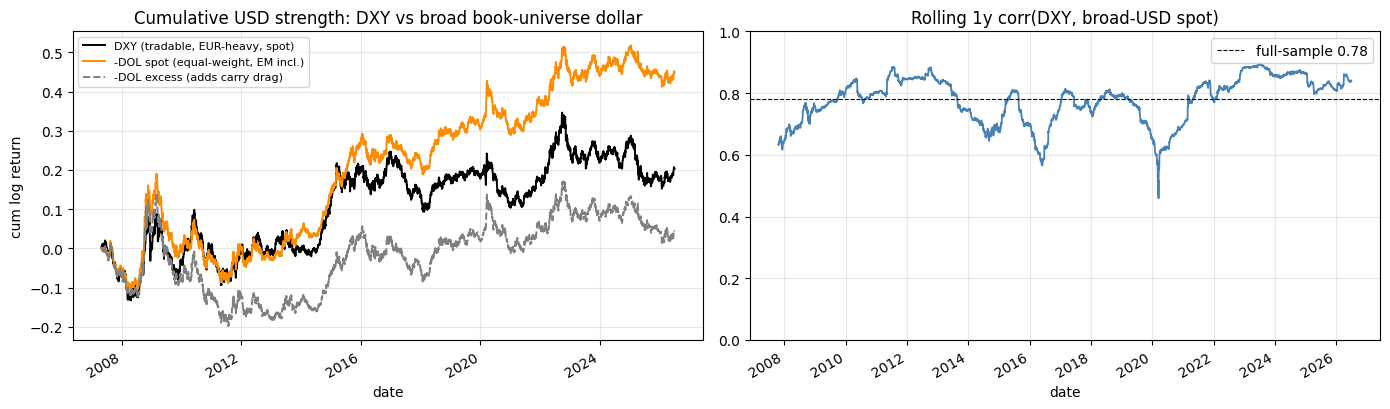

In [4]:
# put both dollars on an "up = USD stronger" footing:
#   DXY return              -> up = USD up (already), a pure SPOT index
#   -DOL (short all FX)     -> up = USD up
# NOTE: dollar_factor(xret) is an EXCESS-return factor, so -DOL_excess is short-all-FX
# *including* the interest differential -> a persistent carry drag vs a spot index.
# The like-for-like comparison to DXY is the SPOT dollar factor.
dol_spot   = fx.dollar_factor(sret[UNIVERSE_ALL])     # equal-weight, spot only
dol_excess = fx.dollar_factor(xret[UNIVERSE_ALL])     # equal-weight, spot + carry (LRV)
usd_spot   = (-dol_spot).rename("USD_broad_spot(-DOL)")
usd_excess = (-dol_excess).rename("USD_broad_excess(-DOL)")

pair = pd.concat([dxy_ret, usd_spot, usd_excess], axis=1).loc[WIN0:WIN1].dropna()
corr_full = pair["DXY"].corr(pair["USD_broad_spot(-DOL)"])
roll_corr = pair["DXY"].rolling(252, min_periods=126).corr(pair["USD_broad_spot(-DOL)"])

cum = pair.cumsum()
print(f"full-sample daily corr(DXY, broad-USD spot)   = {corr_full:.3f}")
print(f"full-sample daily corr(DXY, broad-USD excess) = {pair['DXY'].corr(pair['USD_broad_excess(-DOL)']):.3f}")
print(f"\ncumulative to {WIN1.date()} (log return):")
print(f"  DXY                 {cum['DXY'].iloc[-1]:+.3f}")
print(f"  -DOL spot           {cum['USD_broad_spot(-DOL)'].iloc[-1]:+.3f}   <- composition gap vs DXY")
print(f"  -DOL excess         {cum['USD_broad_excess(-DOL)'].iloc[-1]:+.3f}   <- adds the carry drag")
print(f"\n  gap DXY - (-DOL spot)   = {cum['DXY'].iloc[-1] - cum['USD_broad_spot(-DOL)'].iloc[-1]:+.3f}  (composition)")
print(f"  carry drag              = {cum['USD_broad_spot(-DOL)'].iloc[-1] - cum['USD_broad_excess(-DOL)'].iloc[-1]:+.3f}  (interest differential)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
cum.plot(ax=axes[0], color=["black", "darkorange", "grey"], lw=1.4,
         style=["-", "-", "--"])
axes[0].set_title("Cumulative USD strength: DXY vs broad book-universe dollar")
axes[0].set_ylabel("cum log return")
axes[0].legend(["DXY (tradable, EUR-heavy, spot)",
                "-DOL spot (equal-weight, EM incl.)",
                "-DOL excess (adds carry drag)"], fontsize=8)
roll_corr.plot(ax=axes[1], color="steelblue", lw=1.3)
axes[1].axhline(corr_full, color="k", ls="--", lw=0.8, label=f"full-sample {corr_full:.2f}")
axes[1].set_title("Rolling 1y corr(DXY, broad-USD spot)"); axes[1].set_ylim(0, 1); axes[1].legend()
plt.tight_layout(); plt.show()

> DXY and the broad dollar move together strongly (full-sample daily corr **0.78**) but are **not**
> the same series. The rolling correlation drifts between ~0.45 and ~0.90. It is highest when the
> dollar move is euro-driven (2011–12, 2022–25), unsurprising for a 58%-EUR basket, and troughs
> hardest in COVID (~0.46) and 2016–17 (~0.57).
>
> The cumulative panel separates two effects that the excess-return factor alone confounds. In
> **spot** terms the broad dollar appreciated *more* than DXY (+0.44 vs +0.19), so DXY
> **understates** broad dollar strength by ~0.25 log over the sample, because it omits the EM
> currencies that depreciated hardest. The further ~0.41 drop from the spot factor to the excess
> factor is not dollar divergence at all. It is the **interest differential** paid for being short a
> basket of high yielders, the same carry-vs-spot offset documented in
> `em_carry_attribution.ipynb`.
>
> Both pieces point the same way. DXY tracks the euro bloc and under-reacts to the EM leg. That
> basis is the fundamental limit on how well a DXY overlay can hedge an EM-driven book, and it is
> why the per-currency and book-level betas below, not DXY's own moves, are what we size on.

## 2. Per-currency dollar betas

The first question the futures overlay needs answered: **which legs are dollar-driven, and by how
much?** For each currency $i$ we regress its daily **spot** return on the DXY return:

$$ r^{\,\text{spot}}_{i,t} \;=\; \alpha_i \;+\; \beta_i\, r^{\text{DXY}}_{t} \;+\; \varepsilon_{i,t} $$

- $\beta_i$ is the **hedge ratio**: how much currency $i$ moves per unit DXY move. Because our spots
  are USD-per-FX (up = FX stronger) and DXY is up = USD stronger, we expect $\beta_i < 0$.
- $R^2_i$ is how much of the currency's variance the dollar explains — i.e. **how hedgeable** that
  leg is with DXY at all.
- We use **spot** returns (not excess) for the clean price relationship; the carry accrual is a tiny
  deterministic daily drip that is orthogonal to DXY, so the betas are within rounding of the
  excess-return betas. Standard errors are **Newey–West** (5 daily lags), the repo convention
  (`fx.nw_regression`).

A caveat reads straight off 1: for **EUR** the regression is nearly mechanical (EUR is 57.6% of
DXY), and it is partly mechanical for JPY/GBP/CAD/SEK/CHF. Those betas describe an identity as much
as a hedge; the *informative* betas are the ones on currencies DXY does **not** contain — especially
the EM legs that carry the premium.

In [9]:
# DXY constituent weights (ICE), for flagging the mechanical regressions
DXY_WEIGHTS = {"EUR": 0.576, "JPY": 0.136, "GBP": 0.119, "CAD": 0.091, "SEK": 0.042, "CHF": 0.036}

# estimate on the SAME common window as the book regressions in section 3
rows = {}
for ccy in UNIVERSE_ALL:
    res = fx.nw_regression(win(sret[ccy]), win(dxy_ret).to_frame("DXY"), lags=5)
    if res is None:
        continue
    rows[ccy] = {
        "group":      "G10" if ccy in UNIVERSE_G10 else "EM",
        "beta_dxy":   res["beta_DXY"],
        "t_beta":     res["t_DXY"],
        "r2":         res["r2"],
        "in_dxy":     ccy in DXY_WEIGHTS,
        "dxy_weight": DXY_WEIGHTS.get(ccy, 0.0),
        "n":          res["n"],
    }

missing = [c for c in UNIVERSE_ALL if c not in rows]
if missing:
    print(f"WARNING: no regression returned for {missing}")

# keep the full frame (t-stats and n are saved to CSV for the record)
betas = pd.DataFrame.from_dict(rows, orient="index").sort_values("beta_dxy")

# every t-stat is far past significance at this sample size, so confirm it once
# and then read the display on beta and R2 alone
print(f"Per-currency regression of spot return on DXY, {WIN0.date()} -> {WIN1.date()}")
print(f"all {len(betas)} betas significant (min |t| = {betas['t_beta'].abs().min():.1f}); "
      f"n from {betas['n'].min():,} to {betas['n'].max():,}")

betas[["group", "beta_dxy", "r2", "in_dxy"]].round(3)

Per-currency regression of spot return on DXY, 2007-05-01 -> 2026-06-30
all 27 betas significant (min |t| = 5.7); n from 4,105 to 4,964


,group,beta_dxy,r2,in_dxy
HUF,EM,-1.394,0.538,False
PLN,EM,-1.359,0.569,False
SEK,G10,-1.228,0.598,True
NOK,G10,-1.195,0.502,False
EUR,G10,-1.090,0.844,True
ZAR,EM,-0.974,0.196,False
AUD,G10,-0.971,0.334,False
NZD,G10,-0.964,0.340,False
CHF,G10,-0.950,0.461,True
GBP,G10,-0.866,0.475,True


In [7]:
# --- sanity check: DXY is a weighted basket of exactly these six names, so the
# --- weighted sum of their betas must equal -1 by identity. Any large gap means
# --- a sign-convention or alignment error somewhere upstream.
chk = betas.loc[betas["in_dxy"], ["dxy_weight", "beta_dxy"]].copy()
chk["contribution"] = chk["dxy_weight"] * chk["beta_dxy"]
chk = chk.sort_values("dxy_weight", ascending=False)

implied = chk["contribution"].sum()
print("Weighted-beta identity check (should sum to -1.000):")
print(chk.round(4).to_string())
print(f"\n  weight coverage      {chk['dxy_weight'].sum():.3f}   (must be 1.000)")
print(f"  sum w_i * beta_i     {implied:+.4f}")
print(f"  shortfall vs -1      {implied + 1:+.4f}  ({abs(implied + 1) * 100:.1f}% attenuation)")

if abs(implied + 1) < 0.10:
    print("\n  PASSED. Signs and alignment are consistent; the residual attenuation is what")
    print("  non-synchronous fixings between the Bloomberg DXY print and the spot panel produce.")
else:
    print("\n  FAILED. Check the sign convention on spots vs DXY, or the return alignment.")

Weighted-beta identity check (should sum to -1.000):
     dxy_weight  beta_dxy  contribution
EUR       0.576   -1.0896       -0.6276
JPY       0.136   -0.5672       -0.0771
GBP       0.119   -0.8659       -0.1030
CAD       0.091   -0.6308       -0.0574
SEK       0.042   -1.2281       -0.0516
CHF       0.036   -0.9500       -0.0342

  weight coverage      1.000   (must be 1.000)
  sum w_i * beta_i     -0.9510
  shortfall vs -1      +0.0490  (4.9% attenuation)

  PASSED. Signs and alignment are consistent; the residual attenuation is what
  non-synchronous fixings between the Bloomberg DXY print and the spot panel produce.


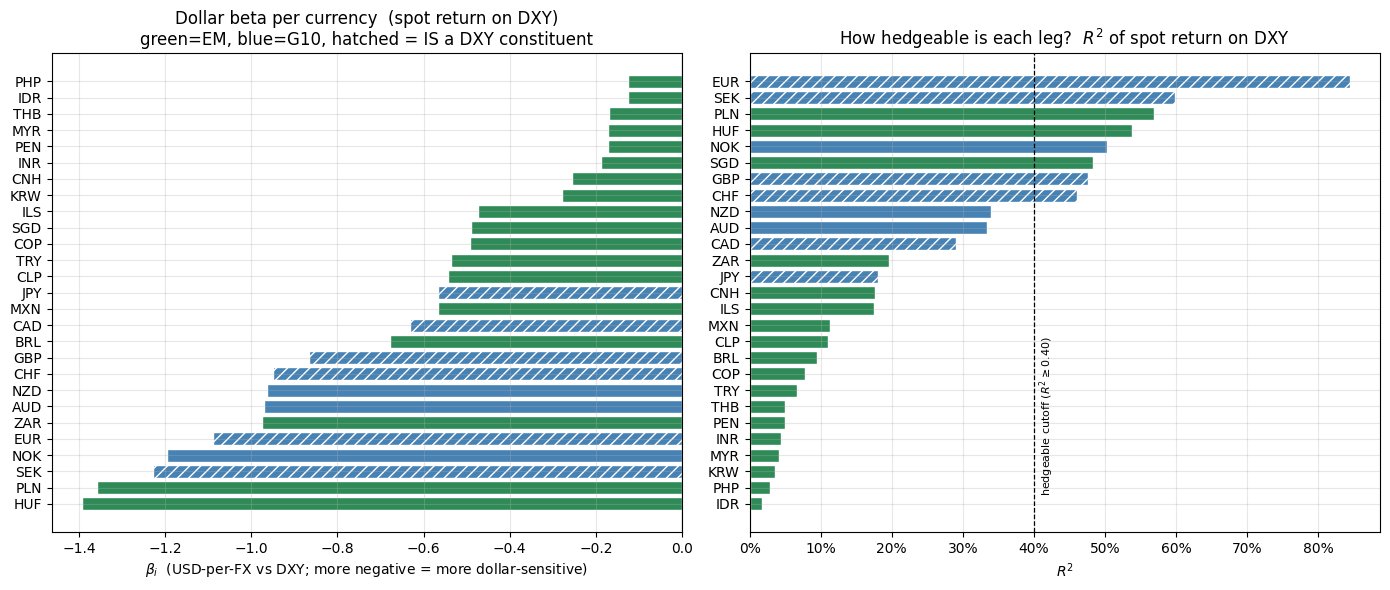

In [13]:
R2_MIN = 0.40  # §6 hedgeable cutoff, defined here so the line can be drawn now

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- betas: hatch the currencies that are mechanically inside DXY ---
b = betas.sort_values("beta_dxy")
colors = ["seagreen" if g == "EM" else "steelblue" for g in b["group"]]
axes[0].barh(b.index, b["beta_dxy"], color=colors,
             hatch=["///" if v else "" for v in b["in_dxy"]],
             edgecolor="white")
axes[0].axvline(0, color="k", lw=0.8)
axes[0].set_title("Dollar beta per currency  (spot return on DXY)\n"
                  "green=EM, blue=G10, hatched = IS a DXY constituent")
axes[0].set_xlabel(r"$\beta_i$  (USD-per-FX vs DXY; more negative = more dollar-sensitive)")

# --- R2: how much of each leg's variance the dollar explains ---
r = betas.sort_values("r2")
colors_r = ["seagreen" if g == "EM" else "steelblue" for g in r["group"]]
axes[1].barh(r.index, r["r2"], color=colors_r,
             hatch=["///" if v else "" for v in r["in_dxy"]], edgecolor="white")
axes[1].axvline(R2_MIN, color="k", ls="--", lw=0.9)
axes[1].text(R2_MIN + 0.005, 0.5, rf"hedgeable cutoff ($R^2 \geq {R2_MIN:.2f}$)",
             fontsize=8, rotation=90, va="bottom", color="k")
axes[1].set_title("How hedgeable is each leg?  $R^2$ of spot return on DXY")
axes[1].set_xlabel(r"$R^2$")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout(); plt.show()

> The split is by **currency bloc, not the G10/EM label**. Every beta is negative (FX weakens when
> the dollar strengthens), but the *European* currencies dominate the top. The largest betas are
> actually **HUF (−1.39) and PLN (−1.36)**, EM by label but CEE currencies that trade as euro
> proxies, alongside SEK/NOK/EUR (−1.1 to −1.2, $R^2$ up to 0.84, EUR near-mechanical as warned).
> The **Asian and managed EM legs load far less** (IDR −0.13, INR/MYR/THB/PHP ≈ −0.15 to −0.19,
> MXN/BRL/TRY/COP ≈ −0.5 to −0.7) with low $R^2$, so much of their variance is idiosyncratic and
> EM-specific, which DXY cannot see. Since the premium *lives* in those low-beta high-yielders, this
> is the crux: **DXY hedges the parts of the book that don't drive the return, and barely sees the
> parts that do.** Whether that nets out to any useful book-level hedge is the next section.

## 3. Book-level dollar beta — the number the overlay sizes on

The overlay is a **single** DXY position against the whole book, so what matters is the book's
*net* dollar beta. We regress each book's **daily net excess return** (its actual P&L) on DXY:

$$ r^{\text{book}}_{t} \;=\; \alpha \;+\; \beta_{\text{book}}\, r^{\text{DXY}}_{t} \;+\; \varepsilon_{t} $$

Interpretation for a **dollar-neutral** book (gross-1 per side): a *uniform* dollar move largely
cancels, so a non-zero $\beta_{\text{book}}$ measures the **residual** tilt from the two legs
responding to the dollar **asymmetrically**. Two opposing forces set its sign:

- **Short funding leg → long USD.** The book shorts the low-yield funding currencies (EUR, SEK,
  CHF, JPY) — and those are the *most* dollar-sensitive names (they essentially *are* the anti-
  dollar; see their large negative betas in §2). Shorting a strongly negative-beta basket makes the
  book **long the dollar** ($\beta_{\text{book}} > 0$).
- **Long EM leg → short USD (crash channel).** The high-yield EM longs fall when the dollar rallies
  in risk-off, pushing $\beta_{\text{book}} < 0$ — but the EM betas are *small* (§2).

Which force wins is empirical. The variance-minimising hedge holds $-\beta_{\text{book}}$ units of
DXY — **short DXY if the book turns out long USD** — and the hedged return is
$r^{\text{book}}_t - \beta_{\text{book}}\, r^{\text{DXY}}_t$. $R^2$ is the in-sample ceiling on how
much book variance that removes. We report gross and net; net is what an overlay actually protects.

In [15]:
def book_on_dxy(book, label):
    res = fx.nw_regression(win(book), win(dxy_ret).to_frame("DXY"), lags=5)
    return {"book": label, "beta_dxy": res["beta_DXY"], "t_beta": res["t_DXY"],
            "r2": res["r2"], "alpha_ann": res["alpha_ann"], "n": res["n"]}

book_reg = pd.DataFrame([book_on_dxy(b, lab) for b, lab in [
    (g10_gross, "G10_gross"), (g10_net, "G10_net"),
    (em_gross, "EM_gross"),   (em_net, "EM_net"),
    (all_gross, "ALL_gross"), (all_net, "ALL_net"),
]]).set_index("book")
print("Book P&L regressed on DXY return (Newey-West, common window):")
book_reg.round(4)

Book P&L regressed on DXY return (Newey-West, common window):


,beta_dxy,t_beta,r2,alpha_ann,n
book,,,,,
G10_gross,-0.0095,-0.2892,0.0000,0.0177,4964
G10_net,-0.0096,-0.2947,0.0000,0.0124,4964
EM_gross,-0.0942,-2.8635,0.0040,0.0671,4964
EM_net,-0.0947,-2.8748,0.0040,0.0426,4964
ALL_gross,0.2990,8.6972,0.0391,0.0671,4964
ALL_net,0.2988,8.6798,0.0390,0.0498,4964


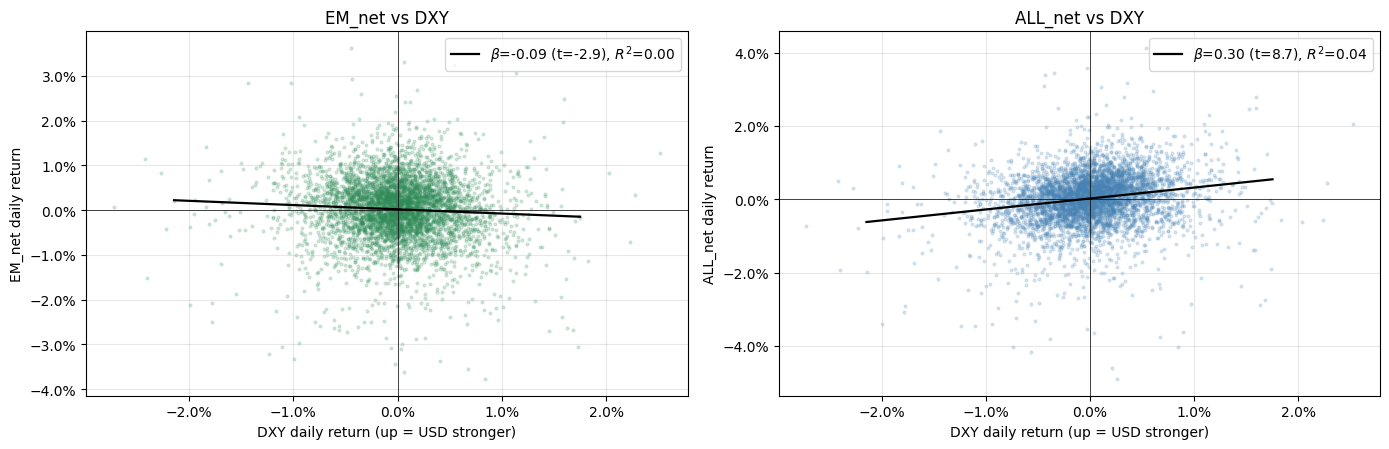

In [16]:
# scatter: book net return vs DXY return, with the OLS fit, for EM-only and combined
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, book, lab, col in [(axes[0], em_net, "EM_net", "seagreen"),
                           (axes[1], all_net, "ALL_net", "steelblue")]:
    df = pd.concat([win(book).rename("book"), dxy_ret.rename("DXY")], axis=1).dropna()
    ax.scatter(df["DXY"], df["book"], s=4, alpha=0.18, color=col)
    beta = book_reg.loc[lab, "beta_dxy"]; a = book_reg.loc[lab, "alpha_ann"] / fx.ANN_DAYS
    xs = np.linspace(df["DXY"].quantile(0.001), df["DXY"].quantile(0.999), 50)
    ax.plot(xs, a + beta * xs, color="black", lw=1.6,
            label=fr"$\beta$={beta:.2f} (t={book_reg.loc[lab,'t_beta']:.1f}), $R^2$={book_reg.loc[lab,'r2']:.2f}")
    ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
    ax.set_xlabel("DXY daily return (up = USD stronger)"); ax.set_ylabel(f"{lab} daily return")
    ax.set_title(f"{lab} vs DXY"); ax.legend(loc="upper right")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout(); plt.show()

> The result is decisive and **not** the naive crash-channel sign. The **combined book is
> structurally _long_ the dollar**: $\beta_{\text{ALL}} = +0.30$ ($t \approx 8.7$), so when the
> dollar rallies the book *gains*. The driver is the **short euro-bloc funding leg** (short
> EUR/SEK/CHF/JPY, the most dollar-sensitive names in §2), which swamps the mild short-USD pull of
> the EM longs. The **EM-only book** shows the textbook sign but tiny: $\beta_{\text{EM}} = -0.09$
> ($t \approx -2.9$, $R^2$ just 0.4%), so the EM crash exposure barely registers against DXY
> *because DXY contains no EM*. The **G10 book** has ~zero beta (a clean dollar-neutral sort). Net
> ≈ gross, so the sizing is robust to the cost basis. Note the wide scatter around both fits: even
> the significant $+0.30$ has $R^2$ of only 3.9%, so this is a **real but small** exposure, not a
> tight one.
>
> The implication is sharp. A DXY overlay on the combined book would mostly be **shorting the dollar
> to unwind the funding leg the carry signal deliberately put on**, fighting its own position, while
> leaving the EM crash risk (the thing we actually want to hedge) almost untouched. DXY measures the
> *mechanical* exposure, not the *risky* one.

## 4. Is the beta stable? Rolling dollar beta

A single full-sample $\beta_{\text{book}}$ hedges the *average* dollar exposure and mis-hedges every
regime — and this project's whole through-line is that the carry premium is **regime-dependent**
(front-loaded, crash-prone, calm-market). So we check the exposure through time with a rolling
1-year beta:

$$ \beta_t \;=\; \frac{\operatorname{Cov}_{t-252\ldots t}\!\left(r^{\text{book}}, r^{\text{DXY}}\right)}
{\operatorname{Var}_{t-252\ldots t}\!\left(r^{\text{DXY}}\right)} $$

If $\beta_t$ swings a lot — and especially if it deepens in crises — then a **static** hedge ratio
is the wrong design and the overlay should use a **trailing (lagged) rolling** beta. That lag is the
same no-lookahead discipline the engine uses everywhere (`ffill().shift(1)`).

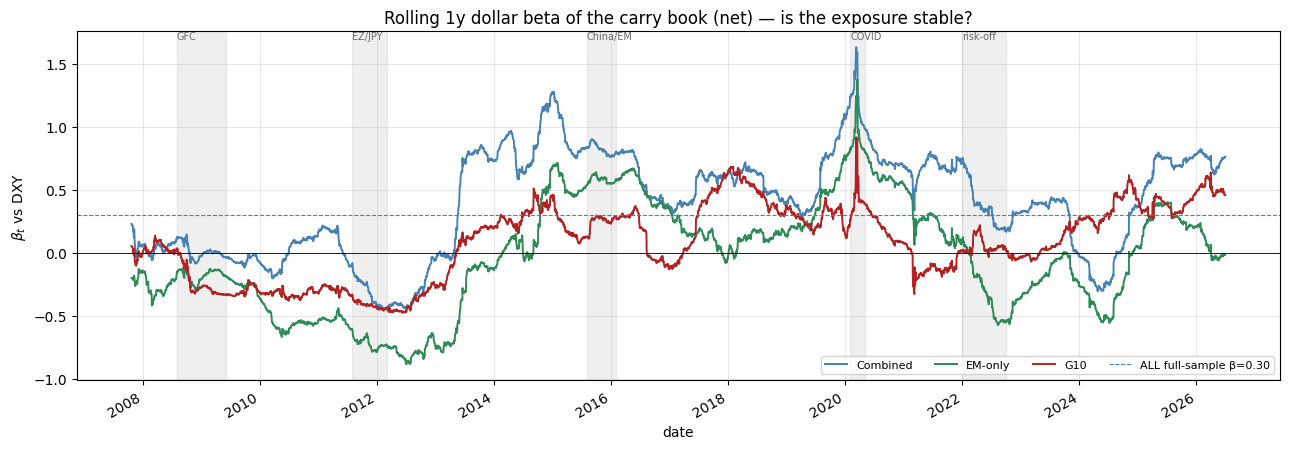

rolling beta dispersion (min / mean / max):
      Combined     EM    G10
min     -0.461 -0.886 -0.477
mean     0.393 -0.030  0.081
max      1.630  1.374  0.915


In [17]:
def rolling_beta(book, x=dxy_ret, window=252, min_periods=126):
    df = pd.concat([book.rename("y"), x.rename("x")], axis=1).dropna()
    cov = df["y"].rolling(window, min_periods=min_periods).cov(df["x"])
    var = df["x"].rolling(window, min_periods=min_periods).var()
    return (cov / var).reindex(book.index)

rb_all = rolling_beta(all_net).loc[WIN0:WIN1]
rb_em  = rolling_beta(em_net).loc[WIN0:WIN1]
rb_g10 = rolling_beta(g10_net).loc[WIN0:WIN1]

# known stress episodes for context shading
CRISES = [("2008-08", "2009-06", "GFC"), ("2011-08", "2012-03", "EZ/JPY"),
          ("2015-08", "2016-02", "China/EM"), ("2020-02", "2020-05", "COVID"),
          ("2022-01", "2022-10", "risk-off")]

fig, ax = plt.subplots(figsize=(13, 4.6))
for s, lab, c in [(rb_all, "Combined", "steelblue"), (rb_em, "EM-only", "seagreen"),
                  (rb_g10, "G10", "firebrick")]:
    s.plot(ax=ax, label=lab, color=c, lw=1.4)
for a, b, lab in CRISES:
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color="grey", alpha=0.12)
    ax.text(pd.Timestamp(a), ax.get_ylim()[1], lab, fontsize=7, va="top", color="dimgray")
ax.axhline(0, color="k", lw=0.6)
ax.axhline(book_reg.loc["ALL_net", "beta_dxy"], color="steelblue", ls="--", lw=0.8,
           label=f"ALL full-sample β={book_reg.loc['ALL_net','beta_dxy']:.2f}")
ax.set_title("Rolling 1y dollar beta of the carry book (net) — is the exposure stable?")
ax.set_ylabel(r"$\beta_t$ vs DXY"); ax.legend(ncol=4, fontsize=8); plt.tight_layout(); plt.show()

print("rolling beta dispersion (min / mean / max):")
print(pd.DataFrame({"Combined": rb_all, "EM": rb_em, "G10": rb_g10}
                   ).agg(["min", "mean", "max"]).round(3).to_string())

> The dollar beta is **not** constant, and not even stable in **sign**. The combined book's rolling
> beta averages **+0.39** but ranges from **−0.46 to +1.63**, swinging with how large the short
> euro-funding leg is and how EM is behaving. It is mostly **positive** (long USD, the funding-leg
> tilt) and spikes highest in COVID, when the dollar-sensitive funding shorts dominate; the EM-only
> book is the one that swings sharply *negative* in stress (min −0.89), the crash channel showing
> through. A single static hedge ratio would therefore be wrong much of the time, so an overlay
> would have to size off a **trailing rolling beta**, the honest no-lookahead version tested in s5.
> But the sign-instability is itself the warning: DXY is capturing a *shifting mechanical exposure*,
> not a stable risk worth hedging with one instrument.

## 5. What would a DXY hedge remove? (in-sample, spot-proxy preview)

This is a **preview, not the backtest** — it uses DXY *spot* returns as a stand-in for the futures
P&L and ignores roll and transaction costs (those come with the real futures data). It answers one
question: if we short the book's dollar beta, what happens to vol and Sharpe? Two hedge ratios:

- **Static** $\hat h = \beta_{\text{book}}$ from §3 — the full-sample, **in-sample** ceiling
  (optimistic; it peeks at the whole window). The combined book has $\beta>0$, so this **shorts DXY**.
- **Dynamic** $\hat h_t = \beta_{t-1}$ — yesterday's trailing rolling beta, **no lookahead** — the
  honest, implementable version.

Hedged return: $r^{\text{hedged}}_t = r^{\text{book}}_t - \hat h\, r^{\text{DXY}}_t$ — i.e. hold
$-\hat h$ units of DXY, so a positive $\hat h$ is a **short-DXY** hedge.

**The real question isn't "does vol fall?"** — a beta hedge mechanically cuts vol. It is **"does
Sharpe improve, or does the hedge sell away compensated premium one-for-one?"** Stage 3 of the team
plan found that de-risking on risk indicators buys tail insurance at ≈zero Sharpe — carry's dollar/
crash exposure is *paid for*. If hedging the dollar beta just scales the book down, Sharpe is flat
and the overlay isn't worth it; if it removes uncompensated variance, Sharpe rises. That is the
hypothesis the futures notebook will test — here we get an in-sample first look.

In [10]:
def hedge(book, h):
    # book minus h*DXY (h scalar or daily Series; h>0 = long USD)
    df = pd.concat([book.rename("book"), dxy_ret.rename("DXY")], axis=1).dropna()
    h_al = h.reindex(df.index) if isinstance(h, pd.Series) else h
    return (df["book"] - h_al * df["DXY"]).rename(book.name)

def hedged_variants(book, rb, label):
    h_static = book_reg.loc[f"{label}_net", "beta_dxy"]           # in-sample scalar; hedged = book - beta*dxy
    h_dyn    = rb.shift(1)                                        # lagged rolling beta, no lookahead
    raw = win(book)
    return pd.concat([
        raw.rename(f"{label}: unhedged"),
        hedge(raw, h_static).rename(f"{label}: static hedge (in-sample)"),
        hedge(raw, h_dyn).rename(f"{label}: dynamic hedge (lagged β)"),
    ], axis=1)

variants = pd.concat([hedged_variants(all_net, rb_all, "ALL"),
                      hedged_variants(em_net, rb_em, "EM")], axis=1)
stats = fx.summary_stats(variants)[["ann_return", "ann_vol", "sharpe", "max_drawdown", "skew"]]
print("In-sample, spot-proxy hedge preview (NOT the futures backtest):")
stats.round(3)

In-sample, spot-proxy hedge preview (NOT the futures backtest):


,ann_return,ann_vol,sharpe,max_drawdown,skew
ALL: unhedged,0.052143,0.111914,0.465923,-0.293185,-0.648005
ALL: static hedge (in-sample),0.049771,0.109988,0.452511,-0.281814,-0.69396
ALL: dynamic hedge (lagged β),0.037589,0.107767,0.348803,-0.330823,-0.702383
EM: unhedged,0.041572,0.110615,0.375827,-0.404703,-0.430505
EM: static hedge (in-sample),0.042647,0.110726,0.385154,-0.398036,-0.425033
EM: dynamic hedge (lagged β),0.030669,0.107465,0.285387,-0.381161,-0.527692


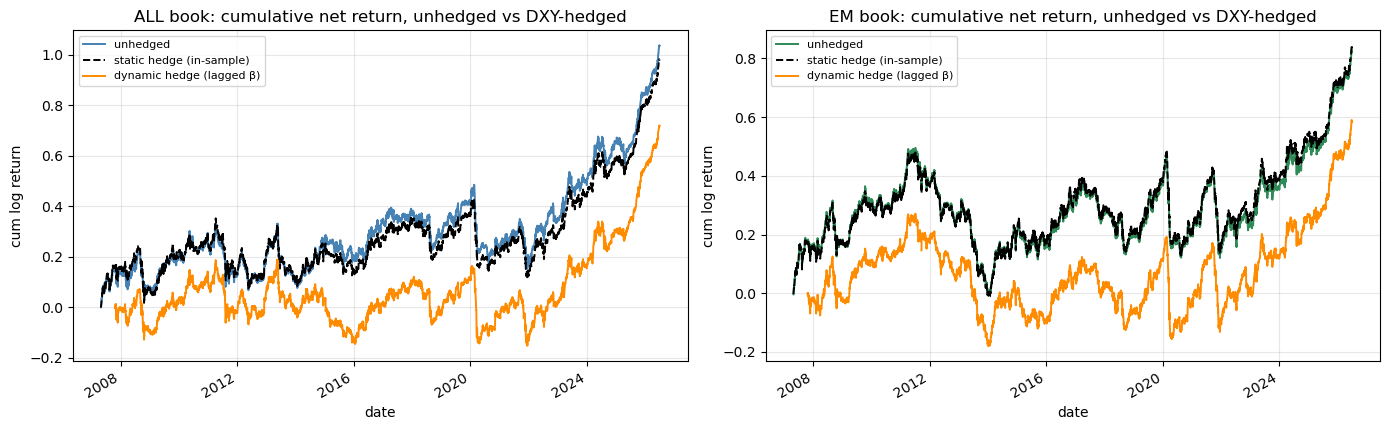

Change vs unhedged (positive vol_reduction = less vol; d_sharpe = Sharpe gain):
                              vol_reduction  d_sharpe  d_maxdd
ALL static hedge (in-sample)          0.017    -0.013    0.011
    dynamic hedge (lagged β)          0.037    -0.117   -0.038
EM  static hedge (in-sample)         -0.001     0.009    0.007
    dynamic hedge (lagged β)          0.028    -0.090    0.024


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, label, base in [(axes[0], "ALL", "steelblue"), (axes[1], "EM", "seagreen")]:
    cols = [c for c in variants.columns if c.startswith(label)]
    styles = ["-", "--", "-"]; cs = [base, "black", "darkorange"]
    for c, ls, col in zip(cols, styles, cs):
        variants[c].cumsum().plot(ax=ax, label=c.split(": ")[1], color=col, ls=ls, lw=1.4)
    ax.set_title(f"{label} book: cumulative net return, unhedged vs DXY-hedged")
    ax.set_ylabel("cum log return"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# concise summary: vol reduction and Sharpe change vs each book's own unhedged track
def delta_row(label):
    u = stats.loc[f"{label}: unhedged"]
    out = {}
    for kind in ["static hedge (in-sample)", "dynamic hedge (lagged β)"]:
        h = stats.loc[f"{label}: {kind}"]
        out[kind] = {"vol_reduction": 1 - h["ann_vol"] / u["ann_vol"],
                     "d_sharpe": h["sharpe"] - u["sharpe"],
                     "d_maxdd": h["max_drawdown"] - u["max_drawdown"]}
    return pd.DataFrame(out).T
print("Change vs unhedged (positive vol_reduction = less vol; d_sharpe = Sharpe gain):")
print(pd.concat({lab: delta_row(lab) for lab in ["ALL", "EM"]}).round(3).to_string())

> The verdict is already discouraging — and this is the *best case* (in-sample, cost-free, optimally
> sized). Even the **static** hedge **lowers the combined book's Sharpe** (0.466 → 0.453, Δ −0.013)
> while shaving only ~2% off vol: it removes a slice of variance that was **compensated**, so return
> falls faster than risk. The **realistic** lagged-beta hedge is worse (Δ Sharpe −0.117) and deepens
> the drawdown, because it chases the unstable §4 beta. The EM book barely moves. This is the Stage-3
> result in a new guise: the book's dollar exposure is *paid for*, so hedging it — **before** we have
> even added futures roll and transaction costs — sells premium roughly one-for-one. A real DXY
> overlay therefore starts this test **behind** and would need the futures data to overturn an
> already-negative in-sample preview to clear the bar (ALL 0.466 / per-ccy RR 0.457).

## 6. Does DXY help where it fits? Hedging only the DXY-tracked names

Sections 3–5 hedged the *whole* book and found DXY mostly captures the euro-funding leg. The natural
follow-up — and the original idea behind this work — is narrower: **restrict to the currencies DXY
actually tracks well, and ask whether a DXY hedge helps _there_.**

We define the **DXY-hedgeable universe** as the names whose spot variance the dollar explains well,
$R^2 \ge 0.40$ from the §2 regressions. These come out as the European bloc (EUR, GBP, CHF, SEK, NOK)
plus the euro-proxy CEE EM (HUF, PLN) and the basket-managed SGD. We then:

1. build a carry book on **only** this subset — a clean "DXY-bloc carry" sub-strategy, median
   long/short (`n_buckets=2`, so all 8 names are used given the small universe), vol-targeted to 10%
   exactly like every other book;
2. regress it on DXY — we expect a **much higher** $R^2$ than the combined book's 3.9%, since this is
   the book DXY was built to track; and
3. run the same static + dynamic hedge preview.

If a DXY hedge is ever going to help a carry book, it should help **here** — on the names DXY
explains. This is the cleanest possible shot for the instrument.

In [18]:
R2_MIN = 0.40
hedgeable = betas.index[betas["r2"] >= R2_MIN].tolist()
print(f"DXY-hedgeable universe (spot R^2 >= {R2_MIN}):  {hedgeable}")
print(betas.loc[hedgeable, ["group", "beta_dxy", "r2"]].round(3).to_string())

# carry book on just these names (median split given the small universe), vol-targeted like the rest
dxyh_gross, dxyh_net, w_dxyh = build_book(hedgeable, 2, "DXYH")

sub_reg = pd.DataFrame([book_on_dxy(b, lab) for b, lab in [
    (dxyh_gross, "DXYH_gross"), (dxyh_net, "DXYH_net")]]).set_index("book")
print("\nDXY-hedgeable carry sub-book regressed on DXY (contrast: ALL_net R^2 was 0.039):")
sub_reg.round(4)

DXY-hedgeable universe (spot R^2 >= 0.4):  ['HUF', 'PLN', 'SEK', 'NOK', 'EUR', 'CHF', 'GBP', 'SGD']
    group  beta_dxy     r2
HUF    EM    -1.394  0.538
PLN    EM    -1.359  0.569
SEK   G10    -1.228  0.598
NOK   G10    -1.195  0.502
EUR   G10    -1.090  0.844
CHF   G10    -0.950  0.461
GBP   G10    -0.866  0.475
SGD    EM    -0.490  0.483

DXY-hedgeable carry sub-book regressed on DXY (contrast: ALL_net R^2 was 0.039):


,beta_dxy,t_beta,r2,alpha_ann,n
book,,,,,
DXYH_gross,-0.1955,-5.6564,0.0165,0.0206,4964
DXYH_net,-0.1957,-5.6547,0.0165,0.0100,4964


In [21]:
# same static (in-sample) + dynamic (lagged) DXY hedge as section 5, on the sub-book
# defined here so this cell runs standalone (it lives in section 5 otherwise)
def hedge(book, h):
    """book minus h*DXY.  h > 0 means holding -h units of DXY, i.e. SHORT DXY."""
    df = pd.concat([book.rename("book"), dxy_ret.rename("DXY")], axis=1, join="inner").dropna()
    h_al = h.reindex(df.index) if isinstance(h, pd.Series) else h
    return (df["book"] - h_al * df["DXY"]).rename(book.name)

def rolling_beta(book, x=None, window=252, min_periods=126):
    x = dxy_ret if x is None else x
    df = pd.concat([book.rename("y"), x.rename("x")], axis=1, join="inner").dropna()
    cov = df["y"].rolling(window, min_periods=min_periods).cov(df["x"])
    var = df["x"].rolling(window, min_periods=min_periods).var()
    return (cov / var).reindex(book.index)

rb_dxyh   = rolling_beta(dxyh_net).loc[WIN0:WIN1]
beta_sub  = sub_reg.loc["DXYH_net", "beta_dxy"]
raw       = win(dxyh_net)
sub_variants = pd.concat([
    raw.rename("DXYH: unhedged"),
    hedge(raw, beta_sub).rename("DXYH: static hedge (in-sample)"),
    hedge(raw, rb_dxyh.shift(1)).rename("DXYH: dynamic hedge (lagged beta)"),
], axis=1)
sub_stats = fx.summary_stats(sub_variants)[["ann_return", "ann_vol", "sharpe", "max_drawdown", "skew"]]
print("DXY-hedgeable sub-book — hedge preview (in-sample, spot-proxy, NOT the futures backtest):")
display(sub_stats.round(3))

u = sub_stats.loc["DXYH: unhedged"]
delta = {}
for kind in ["static hedge (in-sample)", "dynamic hedge (lagged beta)"]:
    h = sub_stats.loc[f"DXYH: {kind}"]
    delta[kind] = {"vol_reduction": 1 - h["ann_vol"] / u["ann_vol"],
                   "d_sharpe": h["sharpe"] - u["sharpe"],
                   "d_maxdd": h["max_drawdown"] - u["max_drawdown"]}
print("\nChange vs unhedged:")
print(pd.DataFrame(delta).T.round(3).to_string())

DXY-hedgeable sub-book — hedge preview (in-sample, spot-proxy, NOT the futures backtest):


,ann_return,ann_vol,sharpe,max_drawdown,skew
DXYH: unhedged,0.008382,0.112862,0.074266,-0.436499,-1.977047
DXYH: static hedge (in-sample),0.009979,0.112143,0.088985,-0.394299,-1.990132
DXYH: dynamic hedge (lagged beta),0.003814,0.10847,0.035159,-0.393747,-2.272097



Change vs unhedged:
                             vol_reduction  d_sharpe  d_maxdd
static hedge (in-sample)             0.006     0.015    0.042
dynamic hedge (lagged beta)          0.039    -0.039    0.043


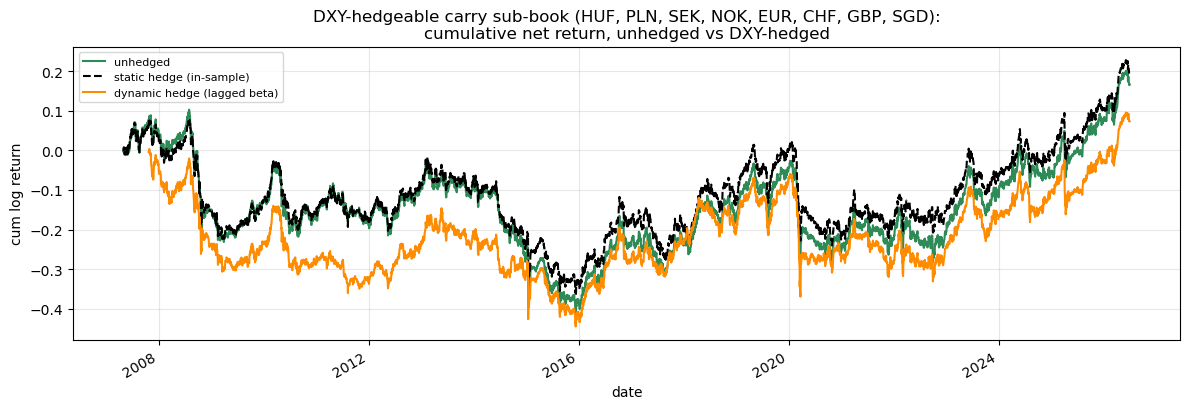

In [14]:
fig, ax = plt.subplots(figsize=(12, 4.2))
for c, ls, col in zip(sub_variants.columns, ["-", "--", "-"], ["seagreen", "black", "darkorange"]):
    sub_variants[c].cumsum().plot(ax=ax, label=c.split(": ")[1], color=col, ls=ls, lw=1.5)
ax.set_title(f"DXY-hedgeable carry sub-book ({', '.join(hedgeable)}):\n"
             "cumulative net return, unhedged vs DXY-hedged")
ax.set_ylabel("cum log return"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

> **Even here — on the eight names DXY tracks best — a DXY hedge does essentially nothing.** Two
> numbers say why. First, the sub-book's beta is a modest **−0.20** and its **$R^2$ is just 1.65% —
> _lower_ than the full combined book's 3.9%** — even though every constituent has a per-name $R^2$ of
> 0.46–0.85. Second, the hedge removes only ~0.6% of vol (static) for a Sharpe change of **+0.015**
> (noise), while the realistic lagged hedge *costs* Sharpe (**−0.039**).
>
> The reason is the crux of the whole exercise: **a carry sort is dollar-neutral, so the common
> dollar cancels across the long and short legs no matter how dollar-sensitive each leg is.** Here the
> sort actually *longs* the **most** dollar-sensitive names (HUF/PLN, $\beta \approx -1.4$) and
> *shorts* the funding names (EUR/CHF/SEK), so most of each leg's large dollar beta nets out; what
> survives is the **relative-value spread** (HUF-vs-CHF, PLN-vs-EUR, …), which DXY does not price.
> High per-currency $R^2$ is therefore a **red herring** for hedging a spread — you cannot hedge a
> dollar-neutral book with the dollar, because the book has already *differenced the dollar away*.
> That, not DXY's basket composition alone, is the deepest reason a DXY overlay has so little to
> hedge.

## 7. Save deliverables

In [15]:
betas.to_csv(OUT / "dxy_currency_betas.csv")
book_reg.to_csv(OUT / "dxy_book_betas.csv")
pd.DataFrame({"ALL_net": rb_all, "EM_net": rb_em, "G10_net": rb_g10}).to_csv(OUT / "dxy_rolling_beta.csv")
stats.to_csv(OUT / "dxy_hedge_preview_stats.csv")
sub_reg.to_csv(OUT / "dxy_subset_book_betas.csv")
sub_stats.to_csv(OUT / "dxy_subset_hedge_stats.csv")
pd.Series(hedgeable, name="ccy").to_csv(OUT / "dxy_hedgeable_universe.csv", index=False)
print("written:", sorted(p.name for p in OUT.glob("dxy_*.csv")))

written: ['dxy_book_betas.csv', 'dxy_currency_betas.csv', 'dxy_hedge_preview_stats.csv', 'dxy_hedgeable_universe.csv', 'dxy_rolling_beta.csv', 'dxy_subset_book_betas.csv', 'dxy_subset_hedge_stats.csv']


## Summary & next steps

**What the measurement step establishes**

1. **DXY is the wrong-shaped dollar for this book** — EUR-heavy, zero EM. It loads heavily on the
   European-bloc legs (EUR/SEK/NOK and even the CEE *EM* names HUF/PLN, which trade as euro proxies)
   and barely on the high-yield EM legs that carry the premium. Its correlation with the broad
   book-universe dollar is high (~0.8) but falls in EM stress — exactly when it would matter.
2. **The combined book is structurally _long_ the dollar** (β = +0.30, t = 8.7), **not** short it.
   The short euro-funding leg (short EUR/SEK/CHF/JPY — the most dollar-sensitive names) dominates, so
   the variance-minimising hedge is to **short DXY** — which largely just unwinds the funding position
   the carry signal deliberately put on. The genuine EM crash exposure barely registers against DXY
   (EM-only β = −0.09, R² = 0.4%) **because DXY contains no EM**.
3. **The beta is unstable in size and even in sign** (rolling −0.46 … +1.63, mean +0.39) — a static
   hedge ratio is the wrong design, and the sign-instability signals DXY is capturing a *shifting
   mechanical exposure*, not a stable risk worth hedging with one instrument.
4. **The in-sample, cost-free preview already reduces Sharpe** (static −0.013 on the combined book,
   dynamic −0.117) — the dollar exposure is compensated, so hedging it sells premium ~1:1. This
   echoes the team's Stage-3 finding that de-risking on risk indicators buys tail insurance at best,
   never Sharpe.
5. **Restricting to the DXY-tracked names doesn't rescue it** (§6). A carry book on only the
   high-$R^2$ subset (EUR/GBP/CHF/SEK/NOK/HUF/PLN/SGD) has an even *lower* book $R^2$ on DXY (1.65%)
   and its hedge is still a wash (static Sharpe +0.015, dynamic −0.039). **A carry sort is
   dollar-neutral, so the common dollar cancels across legs however dollar-sensitive each name is —
   you can't hedge a spread with the dollar.** High per-currency $R^2$ is a red herring.

**Honest read:** on this evidence a DXY overlay looks like a **likely null** for the combined book —
it hedges the euro-funding leg (which the carry signal *wants* on) rather than the EM crash risk
(which DXY can't see), and it costs Sharpe even before futures roll/spreads. And §6 shows it stays a
null even restricted to the names DXY tracks best, because a dollar-neutral carry sort has already
differenced the dollar away. Still worth confirming on the tradable instrument, with eyes open — but
the more promising use of DXY futures may be **directional** (the book *is* structurally long USD, β
= +0.30) rather than as a hedge.

**Next steps (with the Bloomberg terminal)**

- **Pull DXY futures** (`DX1 Curncy` front + generic roll, `PX_LAST` and `PX_BID`/`PX_ASK` for costs)
  and build a continuous, roll-adjusted return series; confirm the ~0.99 return corr with the spot
  index used here so these betas transfer, then reproduce the §3 book regression on the tradable series.
- **Backtest honestly, expecting a null.** Hedge the combined book with static and lagged-rolling
  beta, **net of futures roll + transaction costs**, vs the two bars (ALL 0.466, per-ccy RR 0.457)
  with Newey–West. The in-sample preview already sits behind zero, so this is a falsification test.
- **Re-aim the hedge at the risk, not the mechanics.** DXY sees the euro-funding leg, not EM crash
  risk. Two better-targeted designs: (a) hedge only the **G10/euro-bloc sub-book** with DXY and leave
  EM crash to the per-currency RR hedge; (b) for the EM crash risk itself, use a **broad-/EM-dollar**
  instrument (an EM FX index, or the names DXY omits) — DXY structurally cannot hedge what it does not
  contain.

**Deliverables written:** `outputs/dxy_currency_betas.csv`, `dxy_book_betas.csv`,
`dxy_rolling_beta.csv`, `dxy_hedge_preview_stats.csv`.